# 01 — Exploratory Data Analysis
## Used Car Price Prediction

**Dataset:** Craigslist Cars & Trucks (~426K US listings)  
**Goal:** Understand the data quality, distributions, and relationships between features and the target variable `price` before building any model.

### Contents
1. [Setup & Data Loading](#1-setup)
2. [Dataset Overview](#2-overview)
3. [Missing Value Analysis](#3-missing)
4. [Target Variable — Price](#4-price)
5. [Numerical Features](#5-numerical)
6. [Categorical Features](#6-categorical)
7. [Geographic Analysis](#7-geo)
8. [Feature Correlations](#8-correlations)
9. [Key Insights & Preprocessing Implications](#9-insights)

---
## 1. Setup & Data Loading <a id='1-setup'></a>

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots

# ── Aesthetics ──────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (12, 5)})
SEED = 42

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
RAW_PATH = '../data/raw/vehicles.csv'

# Columns to keep — drop URLs, ids, free-text description, image_url
USE_COLS = [
    'price', 'year', 'manufacturer', 'model', 'condition', 'cylinders',
    'fuel', 'odometer', 'title_status', 'transmission', 'drive',
    'size', 'type', 'paint_color', 'state', 'lat', 'long'
]

df_raw = pd.read_csv(RAW_PATH, usecols=USE_COLS, low_memory=False)
print(f'Loaded: {df_raw.shape[0]:,} rows  x  {df_raw.shape[1]} columns')
df_raw.head()

Loaded: 426,880 rows  x  17 columns


,price,year,manufacturer,model,condition,cylinders,fuel,odometer,title_status,transmission,drive,size,type,paint_color,state,lat,long
0,6000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,az,NaN,NaN
1,11900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ar,NaN,NaN
2,21000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,fl,NaN,NaN
3,1500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,ma,NaN,NaN
4,4900,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nc,NaN,NaN


---
## 2. Dataset Overview <a id='2-overview'></a>

A quick look at data types, memory usage, and the first statistical summary.

In [3]:
print('=== dtypes & non-null counts ===')
df_raw.info(memory_usage='deep')

=== dtypes & non-null counts ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 426880 entries, 0 to 426879
Data columns (total 17 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   price         426880 non-null  int64  
 1   year          425675 non-null  float64
 2   manufacturer  409234 non-null  object 
 3   model         421603 non-null  object 
 4   condition     252776 non-null  object 
 5   cylinders     249202 non-null  object 
 6   fuel          423867 non-null  object 
 7   odometer      422480 non-null  float64
 8   title_status  418638 non-null  object 
 9   transmission  424324 non-null  object 
 10  drive         296313 non-null  object 
 11  size          120519 non-null  object 
 12  type          334022 non-null  object 
 13  paint_color   296677 non-null  object 
 14  state         426880 non-null  object 
 15  lat           420331 non-null  float64
 16  long          420331 non-null  float64
dtypes: float64(4), 

In [4]:
print('=== Numerical summary ===')
df_raw.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).T

=== Numerical summary ===


,count,mean,std,min,1%,5%,25%,50%,75%,95%,99%,max
price,426880.0,75199.033187,1.218228e+07,0.000000,0.000000,0.000000,5900.000000,13950.0000,26485.750000,44500.000000,66995.000000,3.736929e+09
year,425675.0,2011.235191,9.452120e+00,1900.000000,1967.000000,1998.000000,2008.000000,2013.0000,2017.000000,2020.000000,2020.000000,2.022000e+03
odometer,422480.0,98043.331443,2.138815e+05,0.000000,2.000000,6318.000000,37704.000000,85548.0000,133542.500000,204000.000000,280000.000000,1.000000e+07
lat,420331.0,38.493940,5.841533e+00,-84.122245,25.844662,28.301650,34.601900,39.1501,42.398900,46.999600,48.754959,8.239082e+01
long,420331.0,-94.748599,1.836546e+01,-159.827728,-149.869094,-122.579192,-111.939847,-88.4326,-80.832039,-72.967437,-71.081834,1.738855e+02


In [5]:
print('=== Categorical summary ===')
df_raw.describe(include='object').T

=== Categorical summary ===


,count,unique,top,freq
manufacturer,409234,42,ford,70985
model,421603,29667,f-150,8009
condition,252776,6,good,121456
cylinders,249202,8,6 cylinders,94169
fuel,423867,5,gas,356209
title_status,418638,6,clean,405117
transmission,424324,3,automatic,336524
drive,296313,3,4wd,131904
size,120519,4,full-size,63465
type,334022,13,sedan,87056


In [6]:
# Duplicate rows
n_dups = df_raw.duplicated().sum()
print(f'Exact duplicate rows: {n_dups:,}  ({n_dups / len(df_raw) * 100:.2f}%)')

Exact duplicate rows: 97,099  (22.75%)


---
## 3. Missing Value Analysis <a id='3-missing'></a>

In [7]:
missing = (
    df_raw.isnull().sum()
    .rename('missing_count')
    .to_frame()
    .assign(missing_pct=lambda d: d['missing_count'] / len(df_raw) * 100)
    .sort_values('missing_pct', ascending=False)
)
missing

,missing_count,missing_pct
size,306361,71.767476
cylinders,177678,41.622470
condition,174104,40.785232
drive,130567,30.586347
paint_color,130203,30.501078
type,92858,21.752717
manufacturer,17646,4.133714
title_status,8242,1.930753
lat,6549,1.534155
long,6549,1.534155


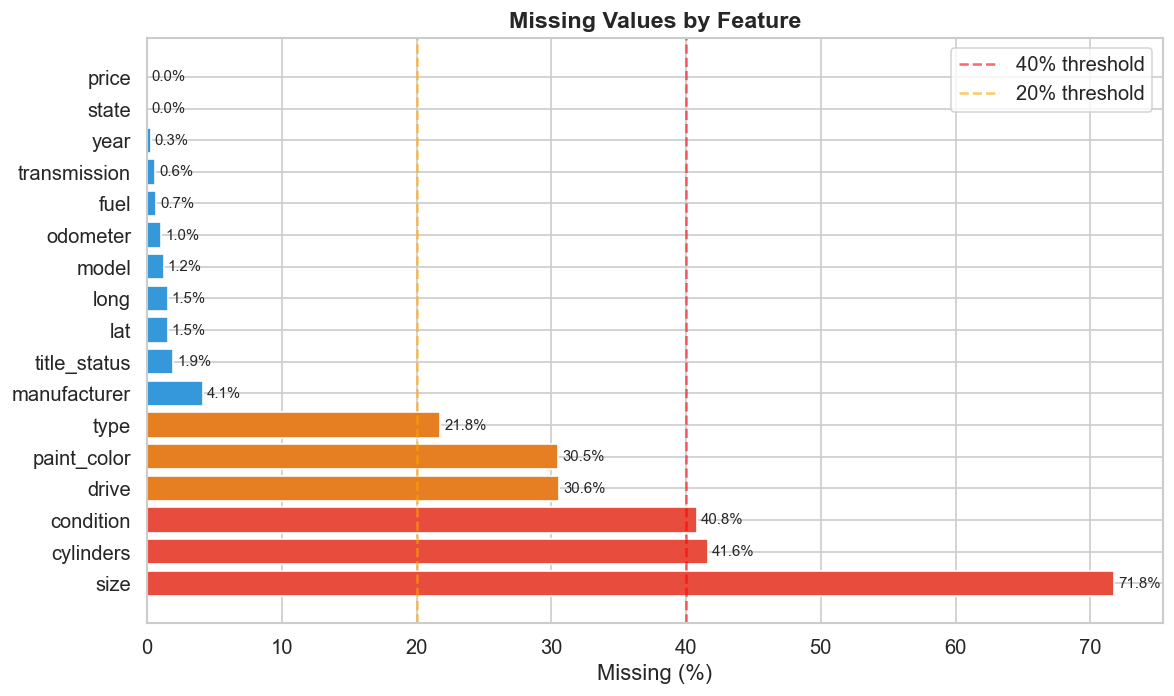

In [8]:
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e74c3c' if p > 40 else '#e67e22' if p > 20 else '#3498db'
          for p in missing['missing_pct']]
bars = ax.barh(missing.index, missing['missing_pct'], color=colors)
ax.set_xlabel('Missing (%)')
ax.set_title('Missing Values by Feature', fontsize=14, fontweight='bold')
ax.axvline(40, color='red', linestyle='--', alpha=0.6, label='40% threshold')
ax.axvline(20, color='orange', linestyle='--', alpha=0.6, label='20% threshold')
for bar, val in zip(bars, missing['missing_pct']):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height() / 2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/01_missing_values.png', bbox_inches='tight')
plt.show()

**Observation:**  
- `size`, `cylinders`, `condition`, `paint_color`, and `drive` have high missing rates (>30%).  
- These will require careful imputation or encoding strategies in the preprocessing step.  
- Features with >60% missing will be candidates for dropping.

---
## 4. Target Variable — Price <a id='4-price'></a>

Price is what we want to predict. We need to understand its distribution, detect impossible values, and decide whether a log-transformation makes sense.

In [9]:
price = df_raw['price'].dropna()
print(f'Price stats (raw):')
print(price.describe(percentiles=[.01, .05, .25, .5, .75, .95, .99]).to_string())

Price stats (raw):
count    4.268800e+05
mean     7.519903e+04
std      1.218228e+07
min      0.000000e+00
1%       0.000000e+00
5%       0.000000e+00
25%      5.900000e+03
50%      1.395000e+04
75%      2.648575e+04
95%      4.450000e+04
99%      6.699500e+04
max      3.736929e+09


In [10]:
# Realistic price window — cars are almost never free or >$200K on Craigslist
PRICE_MIN, PRICE_MAX = 500, 150_000
price_filtered = price[(price >= PRICE_MIN) & (price <= PRICE_MAX)]
removed = len(price) - len(price_filtered)
print(f'Rows with price outside [{PRICE_MIN:,}, {PRICE_MAX:,}]: {removed:,}  '
      f'({removed / len(price) * 100:.2f}%)')

Rows with price outside [500, 150,000]: 42,290  (9.91%)


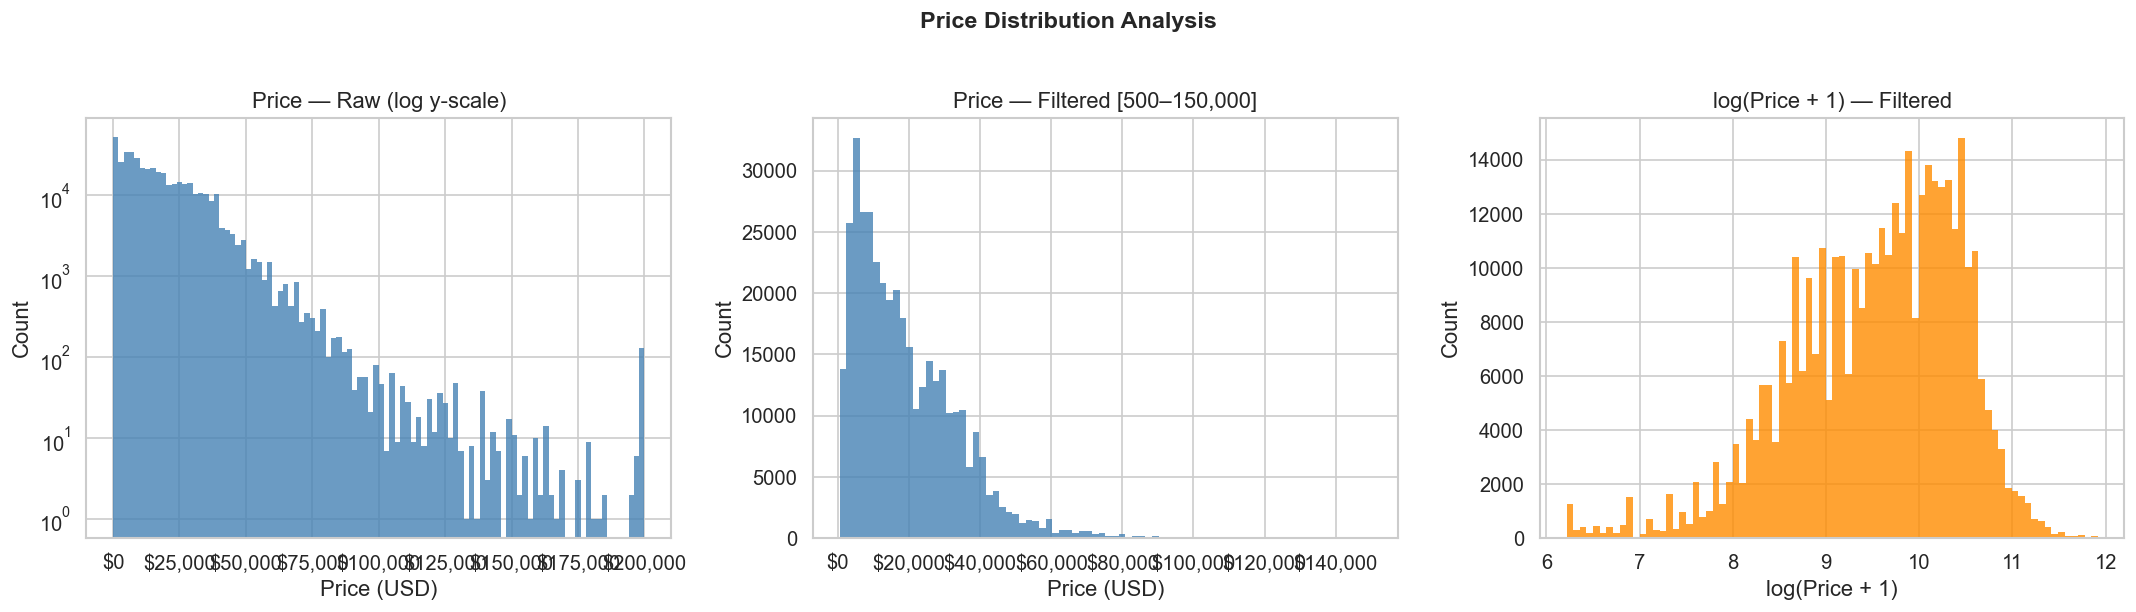

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Raw distribution (log scale for visibility)
axes[0].hist(price.clip(0, 200_000), bins=100, color='steelblue', edgecolor='none', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title('Price — Raw (log y-scale)')
axes[0].set_xlabel('Price (USD)')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Filtered distribution
axes[1].hist(price_filtered, bins=80, color='steelblue', edgecolor='none', alpha=0.8)
axes[1].set_title(f'Price — Filtered [{PRICE_MIN:,}–{PRICE_MAX:,}]')
axes[1].set_xlabel('Price (USD)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

# Log-transformed distribution
axes[2].hist(np.log1p(price_filtered), bins=80, color='darkorange', edgecolor='none', alpha=0.8)
axes[2].set_title('log(Price + 1) — Filtered')
axes[2].set_xlabel('log(Price + 1)')

for ax in axes:
    ax.set_ylabel('Count')

plt.suptitle('Price Distribution Analysis', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/02_price_distribution.png', bbox_inches='tight')
plt.show()

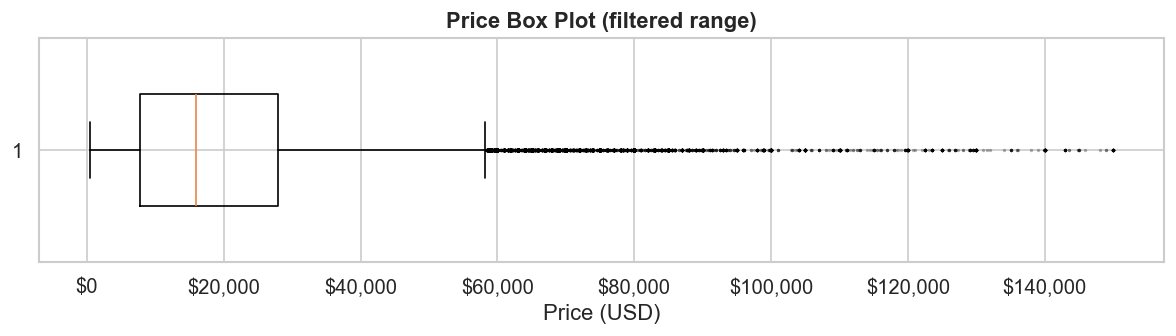

IQR-based outliers: 7,588  (2.0%)
Q1=$7,800  Median=$15,900  Q3=$27,990  IQR=$20,190


In [12]:
# Box plot showing extreme outliers
fig, ax = plt.subplots(figsize=(10, 3))
ax.boxplot(price_filtered, vert=False, widths=0.5,
           flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.set_xlabel('Price (USD)')
ax.set_title('Price Box Plot (filtered range)', fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
plt.tight_layout()
plt.show()

# IQR outlier count
q1, q3 = price_filtered.quantile(0.25), price_filtered.quantile(0.75)
iqr = q3 - q1
outliers_iqr = ((price_filtered < q1 - 1.5 * iqr) | (price_filtered > q3 + 1.5 * iqr)).sum()
print(f'IQR-based outliers: {outliers_iqr:,}  ({outliers_iqr / len(price_filtered) * 100:.1f}%)')
print(f'Q1=${q1:,.0f}  Median=${price_filtered.median():,.0f}  Q3=${q3:,.0f}  IQR=${iqr:,.0f}')

**Key findings:**
- The raw price distribution is **heavily right-skewed** with many placeholder values (0, 1, 123456…).
- After filtering to `[$500, $150,000]`, the distribution is still right-skewed but realistic.
- A **log-transformation** makes the distribution closer to normal — this will benefit linear models and reduce the influence of expensive outliers on tree-based models.
- **Decision:** Train on `log1p(price)`; back-transform predictions with `expm1`.

---
## 5. Numerical Features <a id='5-numerical'></a>

The two key continuous predictors are **`year`** (proxy for vehicle age) and **`odometer`** (mileage).

In [13]:
# Working subset: apply the price filter to build a consistent analysis frame
df = df_raw[(df_raw['price'] >= PRICE_MIN) & (df_raw['price'] <= PRICE_MAX)].copy()
df['log_price'] = np.log1p(df['price'])
print(f'Analysis frame: {df.shape[0]:,} rows')

Analysis frame: 384,590 rows


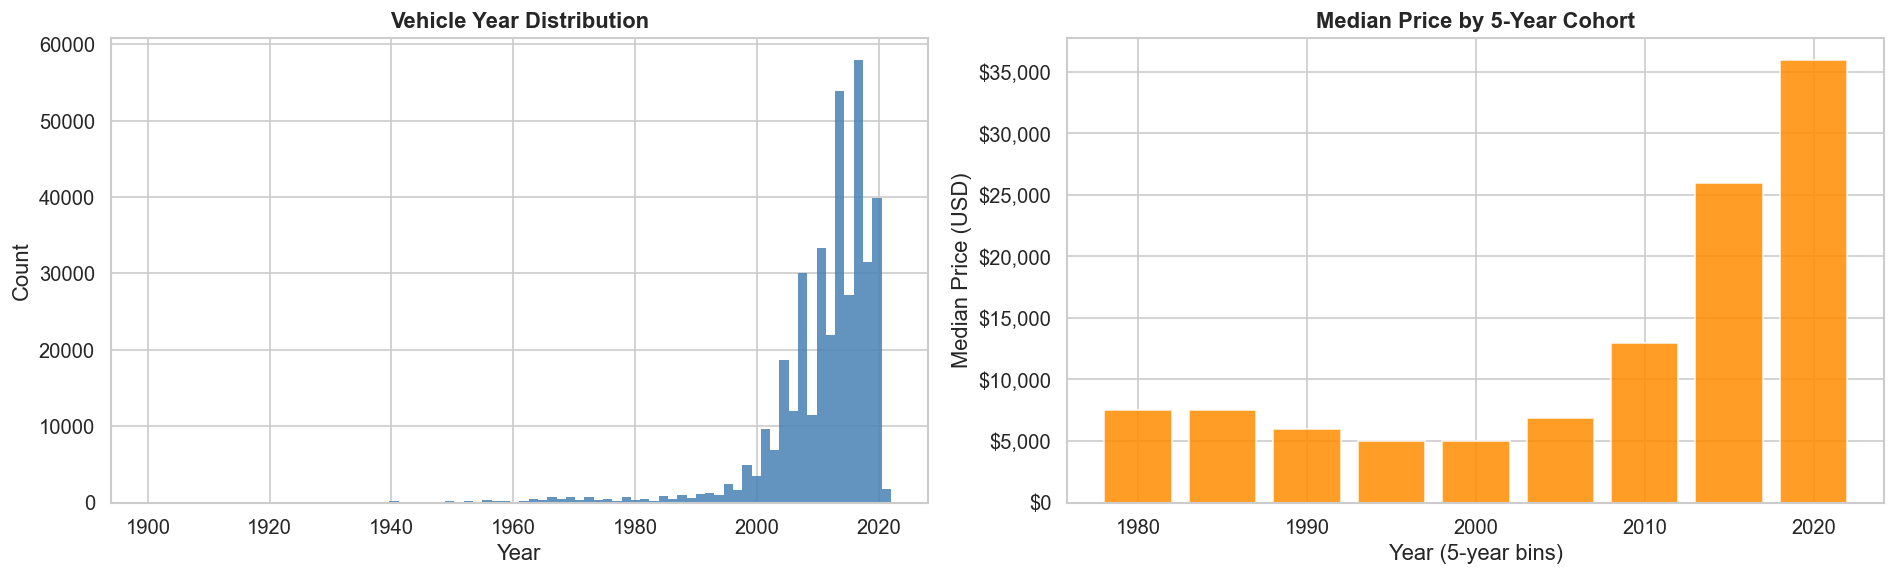

Year: min=1900  max=2022  median=2013  missing=1,173


In [14]:
# --- Year ---
CURRENT_YEAR = 2025
year_valid = df['year'].dropna()
year_valid = year_valid[(year_valid >= 1900) & (year_valid <= CURRENT_YEAR)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(year_valid, bins=80, color='steelblue', edgecolor='none', alpha=0.85)
axes[0].set_title('Vehicle Year Distribution', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')

# Median price by decade
df_year = df[df['year'].between(1980, CURRENT_YEAR)].copy()
df_year['decade'] = (df_year['year'] // 5 * 5).astype(int)
decade_price = df_year.groupby('decade')['price'].median().reset_index()
axes[1].bar(decade_price['decade'], decade_price['price'],
            color='darkorange', alpha=0.85, width=4)
axes[1].set_title('Median Price by 5-Year Cohort', fontweight='bold')
axes[1].set_xlabel('Year (5-year bins)')
axes[1].set_ylabel('Median Price (USD)')
axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))

plt.tight_layout()
plt.savefig('../reports/figures/03_year_analysis.png', bbox_inches='tight')
plt.show()

print(f'Year: min={year_valid.min():.0f}  max={year_valid.max():.0f}  '
      f'median={year_valid.median():.0f}  missing={df["year"].isna().sum():,}')

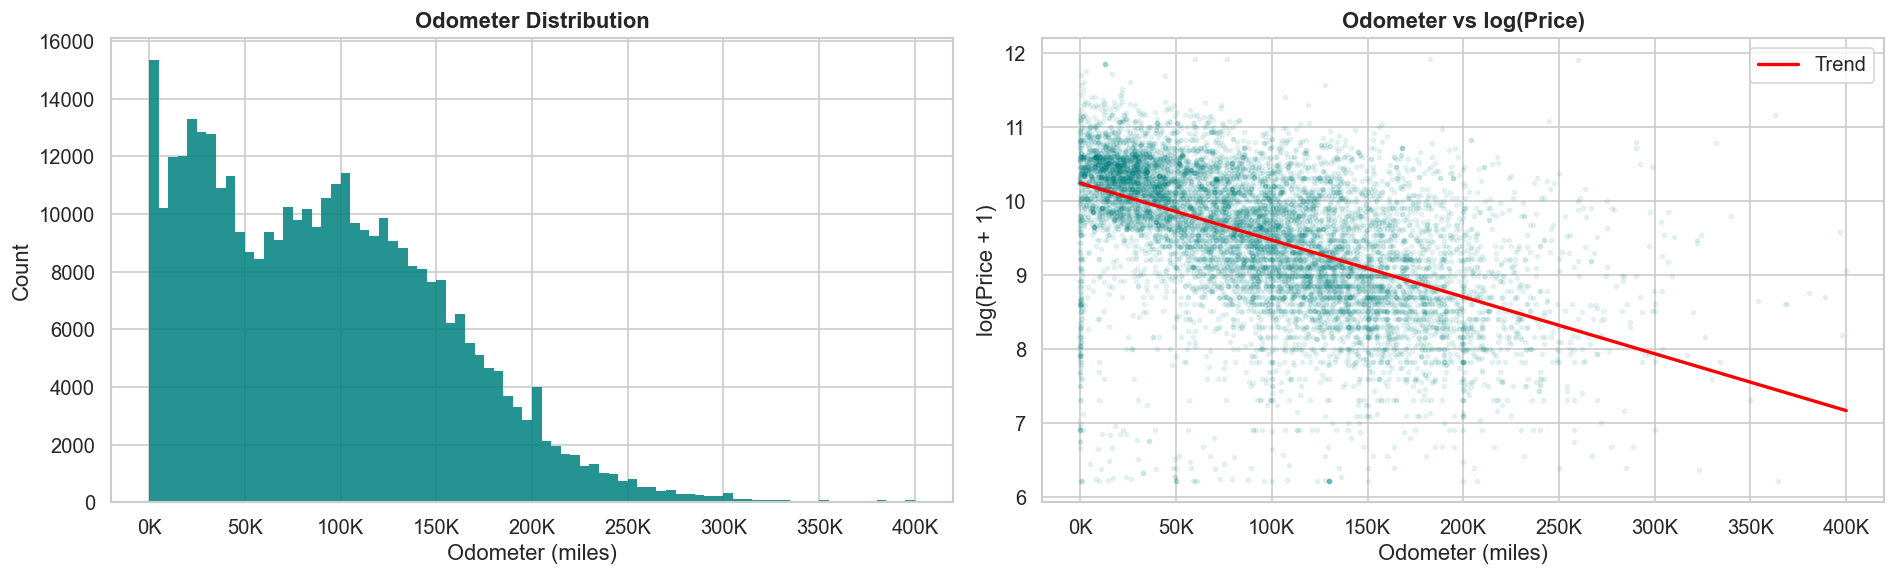

Pearson r(odometer, log_price) = -0.206


In [15]:
# --- Odometer ---
ODO_MAX = 400_000
odo = df['odometer'].dropna()
odo_filtered = odo[(odo >= 0) & (odo <= ODO_MAX)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

axes[0].hist(odo_filtered, bins=80, color='teal', edgecolor='none', alpha=0.85)
axes[0].set_title('Odometer Distribution', fontweight='bold')
axes[0].set_xlabel('Odometer (miles)')
axes[0].set_ylabel('Count')
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))

# Odometer vs log-price scatter (sampled for speed)
sample = df[df['odometer'].between(0, ODO_MAX)].sample(10_000, random_state=SEED)
axes[1].scatter(sample['odometer'], sample['log_price'],
                alpha=0.08, s=6, color='teal')
# Trend line
z = np.polyfit(sample['odometer'].dropna(),
               sample.loc[sample['odometer'].notna(), 'log_price'], 1)
p = np.poly1d(z)
xline = np.linspace(0, ODO_MAX, 300)
axes[1].plot(xline, p(xline), color='red', linewidth=2, label='Trend')
axes[1].set_title('Odometer vs log(Price)', fontweight='bold')
axes[1].set_xlabel('Odometer (miles)')
axes[1].set_ylabel('log(Price + 1)')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
axes[1].legend()

plt.tight_layout()
plt.savefig('../reports/figures/04_odometer_analysis.png', bbox_inches='tight')
plt.show()

corr_odo = df[['odometer', 'log_price']].dropna().corr().iloc[0, 1]
print(f'Pearson r(odometer, log_price) = {corr_odo:.3f}')

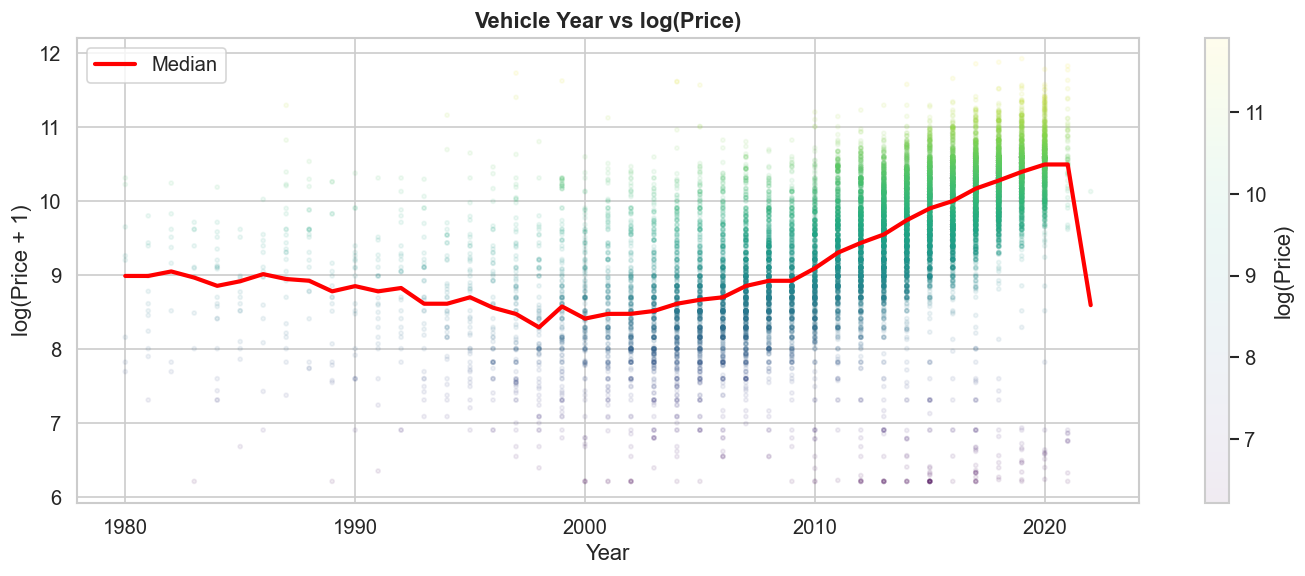

In [16]:
# Year vs price — scatter + trend
sample_yr = df[df['year'].between(1980, CURRENT_YEAR)].sample(15_000, random_state=SEED)

fig, ax = plt.subplots(figsize=(12, 5))
sc = ax.scatter(sample_yr['year'], sample_yr['log_price'],
                alpha=0.08, s=6, c=sample_yr['log_price'], cmap='viridis')
plt.colorbar(sc, ax=ax, label='log(Price)')

# Median line
median_by_year = df[df['year'].between(1980, CURRENT_YEAR)].groupby('year')['price'].median()
ax.plot(median_by_year.index, np.log1p(median_by_year.values),
        color='red', linewidth=2.5, label='Median')

ax.set_title('Vehicle Year vs log(Price)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('log(Price + 1)')
ax.legend()
plt.tight_layout()
plt.savefig('../reports/figures/05_year_vs_price.png', bbox_inches='tight')
plt.show()

**Key findings:**
- **Year** has a strong positive relationship with price — newer cars cost more. The relationship is nonlinear (exponential near 2015–2023).
- **Odometer** has a clear negative correlation with price. Higher mileage → lower price.
- Both features will be among the **top predictors** in every model.

---
## 6. Categorical Features <a id='6-categorical'></a>

In [17]:
def plot_cat_price(col, top_n=15, figsize=(14, 5), title=None):
    """Bar chart: median price ± IQR for the top_n categories of `col`."""
    tmp = df.dropna(subset=[col, 'price'])
    top_cats = tmp[col].value_counts().head(top_n).index
    tmp = tmp[tmp[col].isin(top_cats)]
    
    stats = (
        tmp.groupby(col)['price']
        .agg(median='median', q1=lambda x: x.quantile(0.25),
             q3=lambda x: x.quantile(0.75), count='count')
        .sort_values('median', ascending=False)
        .reset_index()
    )
    
    fig, axes = plt.subplots(1, 2, figsize=figsize)
    
    # Left: median price
    axes[0].barh(stats[col], stats['median'] / 1000, color='steelblue', alpha=0.85)
    axes[0].set_xlabel('Median Price ($K)')
    axes[0].set_title(f'Median Price by {col}', fontweight='bold')
    axes[0].invert_yaxis()
    
    # Right: count distribution
    axes[1].barh(stats[col], stats['count'] / 1000, color='darkorange', alpha=0.85)
    axes[1].set_xlabel('Listing Count (K)')
    axes[1].set_title(f'Listing Count by {col}', fontweight='bold')
    axes[1].invert_yaxis()
    
    plt.suptitle(title or f'Analysis of `{col}`', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig(f'../reports/figures/cat_{col}.png', bbox_inches='tight')
    plt.show()

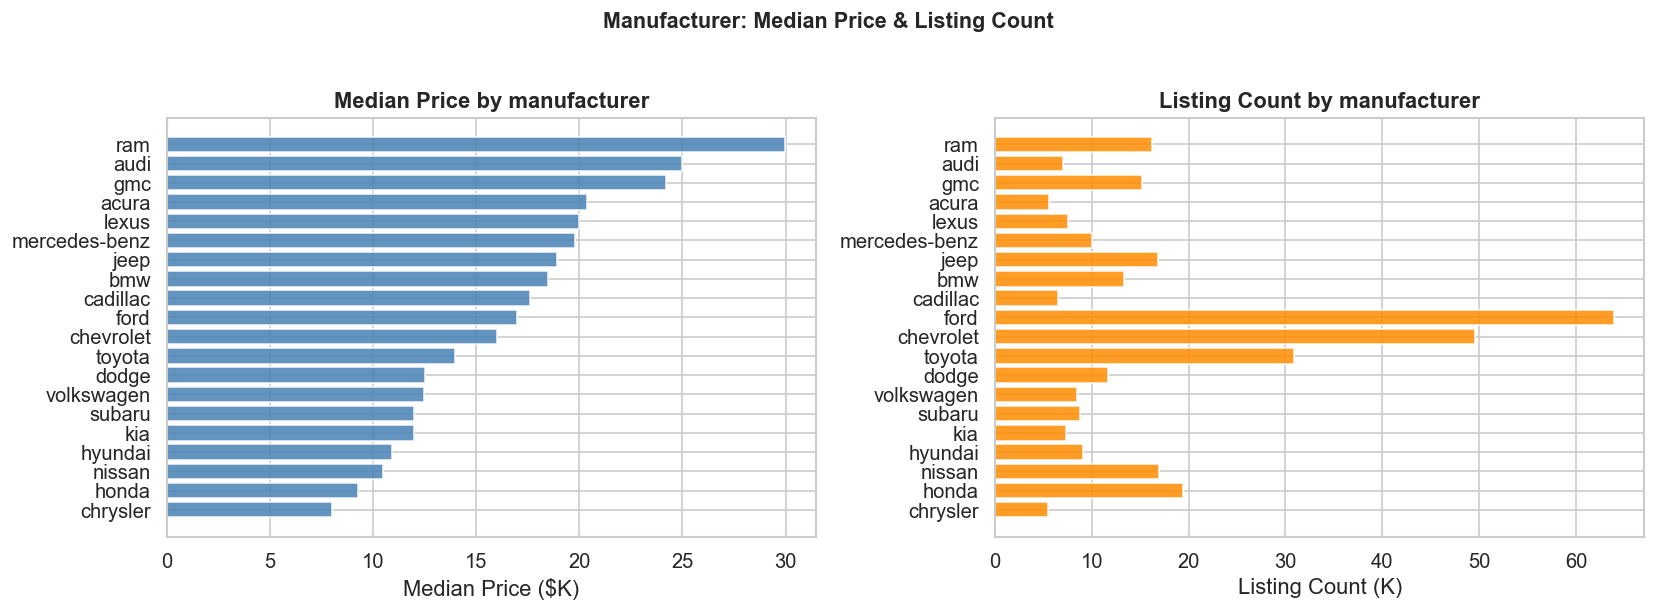

In [18]:
# ── Manufacturer ─────────────────────────────────────────────────────────────
plot_cat_price('manufacturer', top_n=20, title='Manufacturer: Median Price & Listing Count')

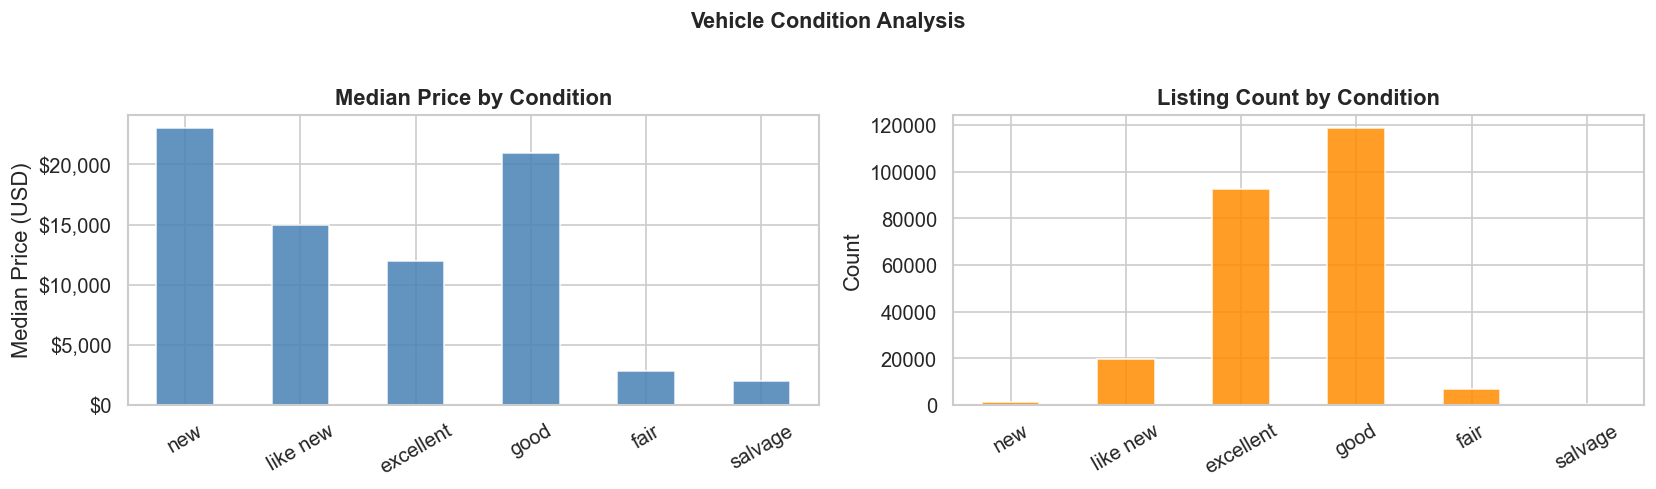

In [19]:
# ── Condition ────────────────────────────────────────────────────────────────
CONDITION_ORDER = ['new', 'like new', 'excellent', 'good', 'fair', 'salvage']
cond_data = (
    df.dropna(subset=['condition', 'price'])
    .groupby('condition')['price']
    .agg(['median', 'count'])
    .reindex([c for c in CONDITION_ORDER if c in df['condition'].unique()])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cond_data['median'].plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Median Price by Condition', fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Median Price (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

cond_data['count'].plot(kind='bar', ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title('Listing Count by Condition', fontweight='bold')
axes[1].set_xlabel('')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Vehicle Condition Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/cat_condition.png', bbox_inches='tight')
plt.show()

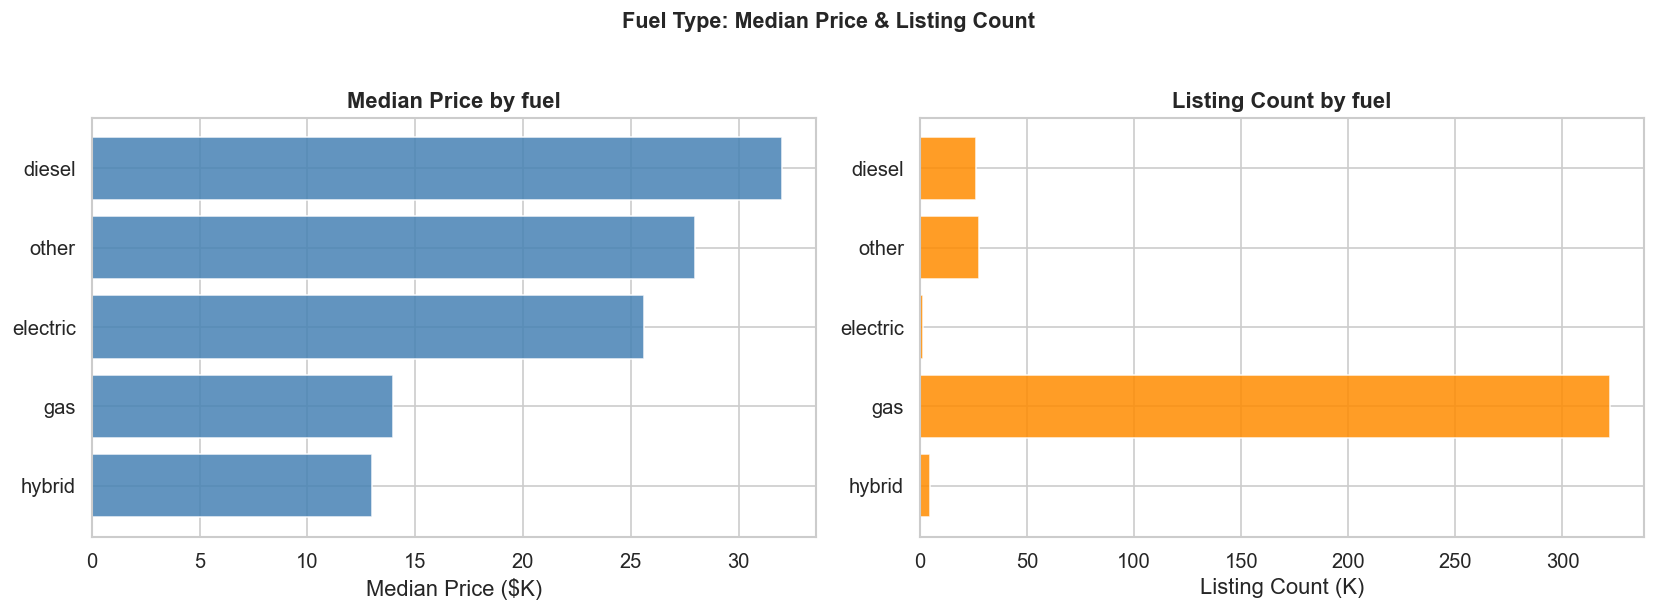

In [20]:
# ── Fuel type ────────────────────────────────────────────────────────────────
plot_cat_price('fuel', top_n=10, title='Fuel Type: Median Price & Listing Count')

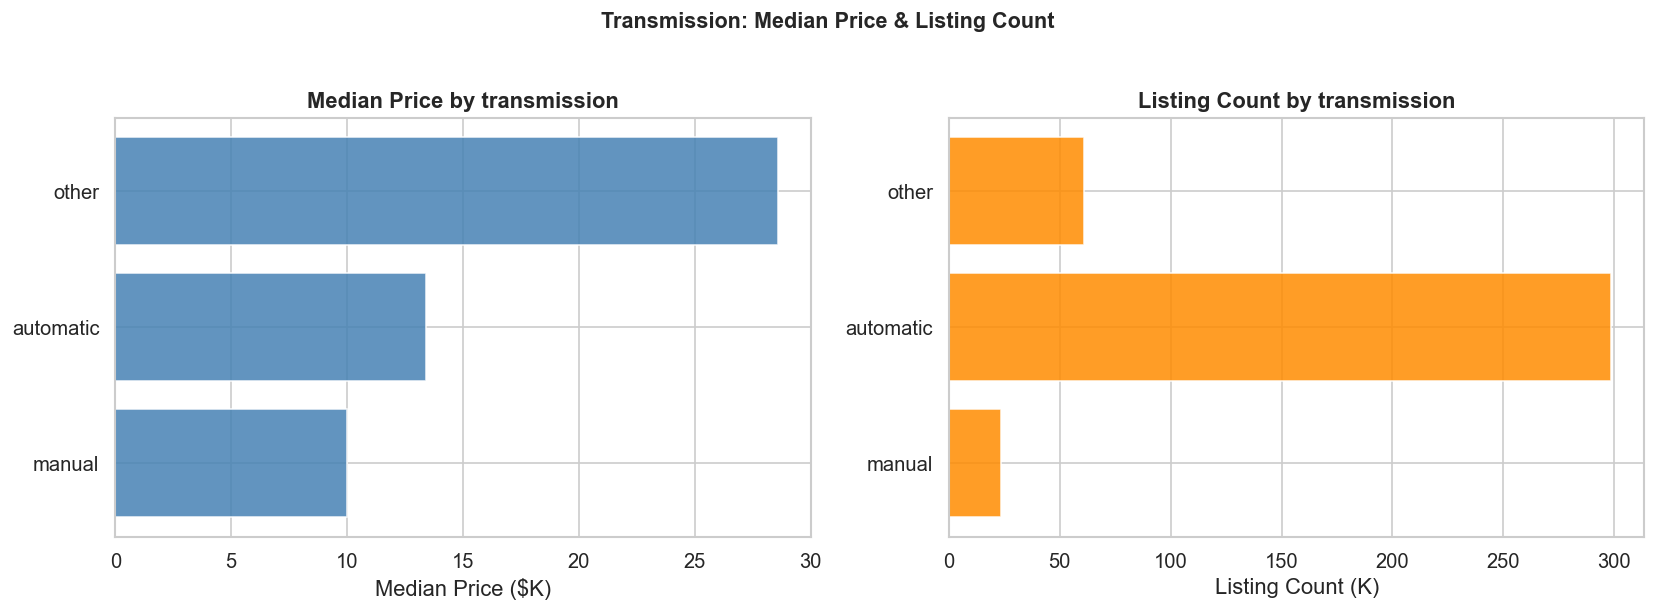

In [21]:
# ── Transmission ────────────────────────────────────────────────────────────
plot_cat_price('transmission', top_n=5, title='Transmission: Median Price & Listing Count')

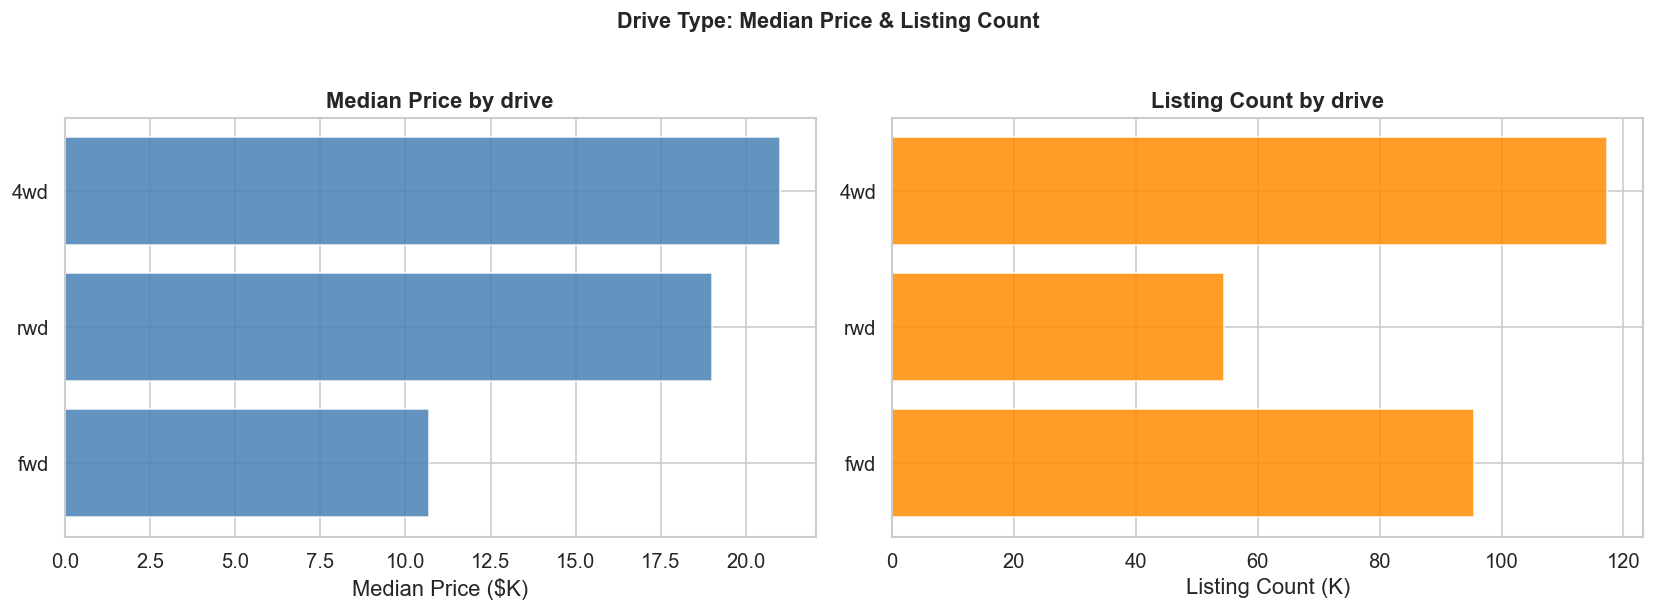

In [22]:
# ── Drive ────────────────────────────────────────────────────────────────────
plot_cat_price('drive', top_n=5, title='Drive Type: Median Price & Listing Count')

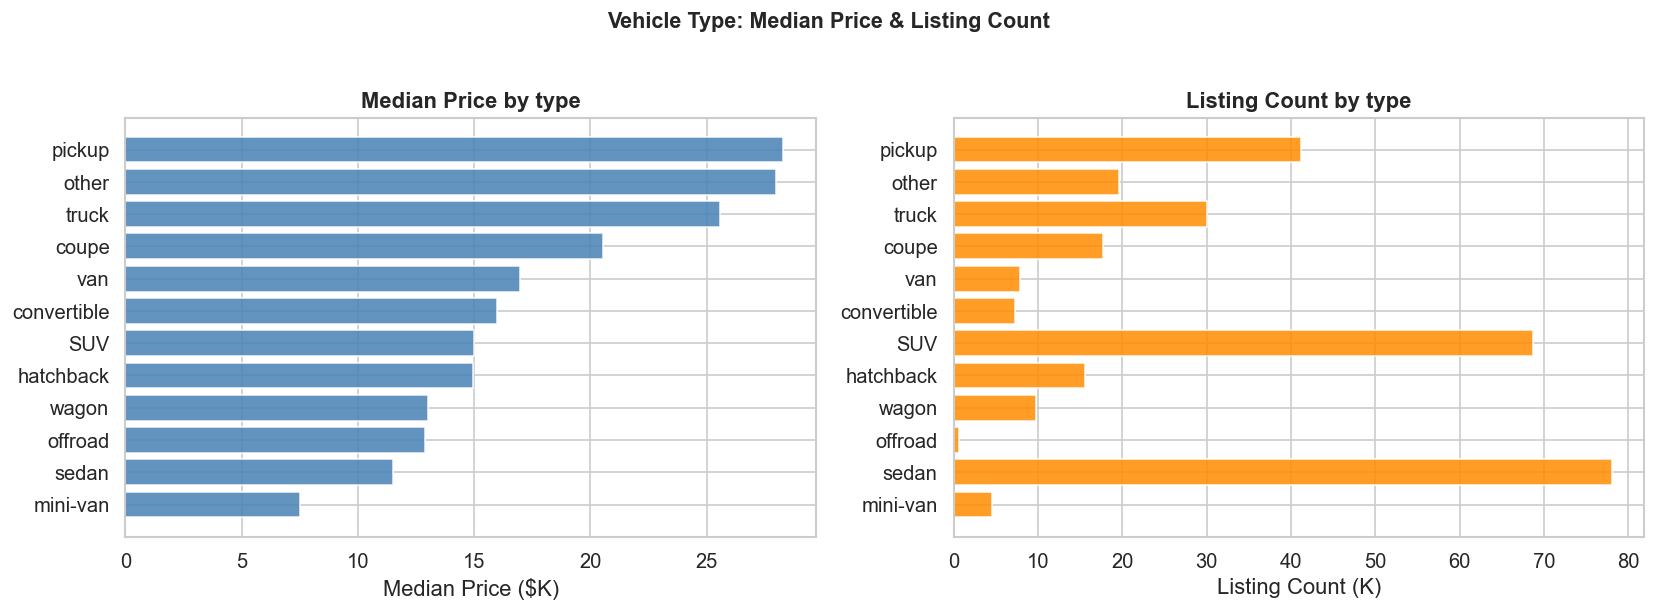

In [23]:
# ── Vehicle type ────────────────────────────────────────────────────────────
plot_cat_price('type', top_n=12, title='Vehicle Type: Median Price & Listing Count')

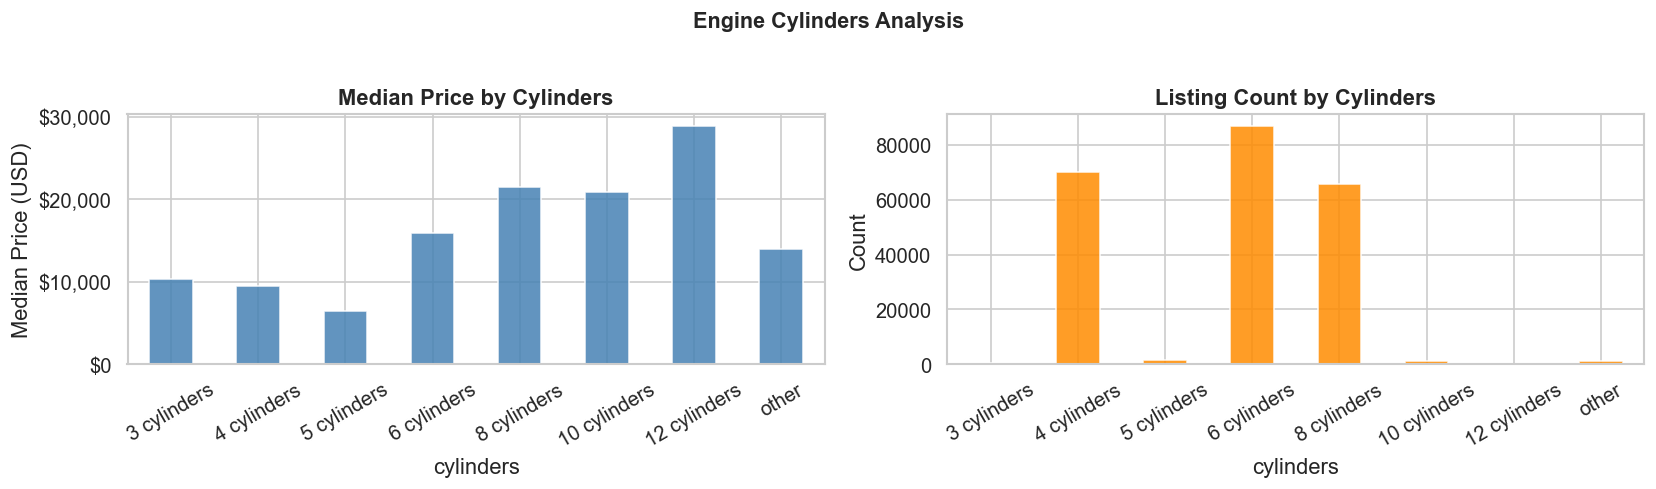

In [24]:
# ── Cylinders ────────────────────────────────────────────────────────────────
cyl_order = ['3 cylinders', '4 cylinders', '5 cylinders', '6 cylinders',
             '8 cylinders', '10 cylinders', '12 cylinders', 'other']

cyl_data = (
    df.dropna(subset=['cylinders', 'price'])
    .groupby('cylinders')['price']
    .agg(['median', 'count'])
    .reindex([c for c in cyl_order if c in df['cylinders'].unique()])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
cyl_data['median'].plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.85)
axes[0].set_title('Median Price by Cylinders', fontweight='bold')
axes[0].set_ylabel('Median Price (USD)')
axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].tick_params(axis='x', rotation=30)

cyl_data['count'].plot(kind='bar', ax=axes[1], color='darkorange', alpha=0.85)
axes[1].set_title('Listing Count by Cylinders', fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=30)

plt.suptitle('Engine Cylinders Analysis', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../reports/figures/cat_cylinders.png', bbox_inches='tight')
plt.show()

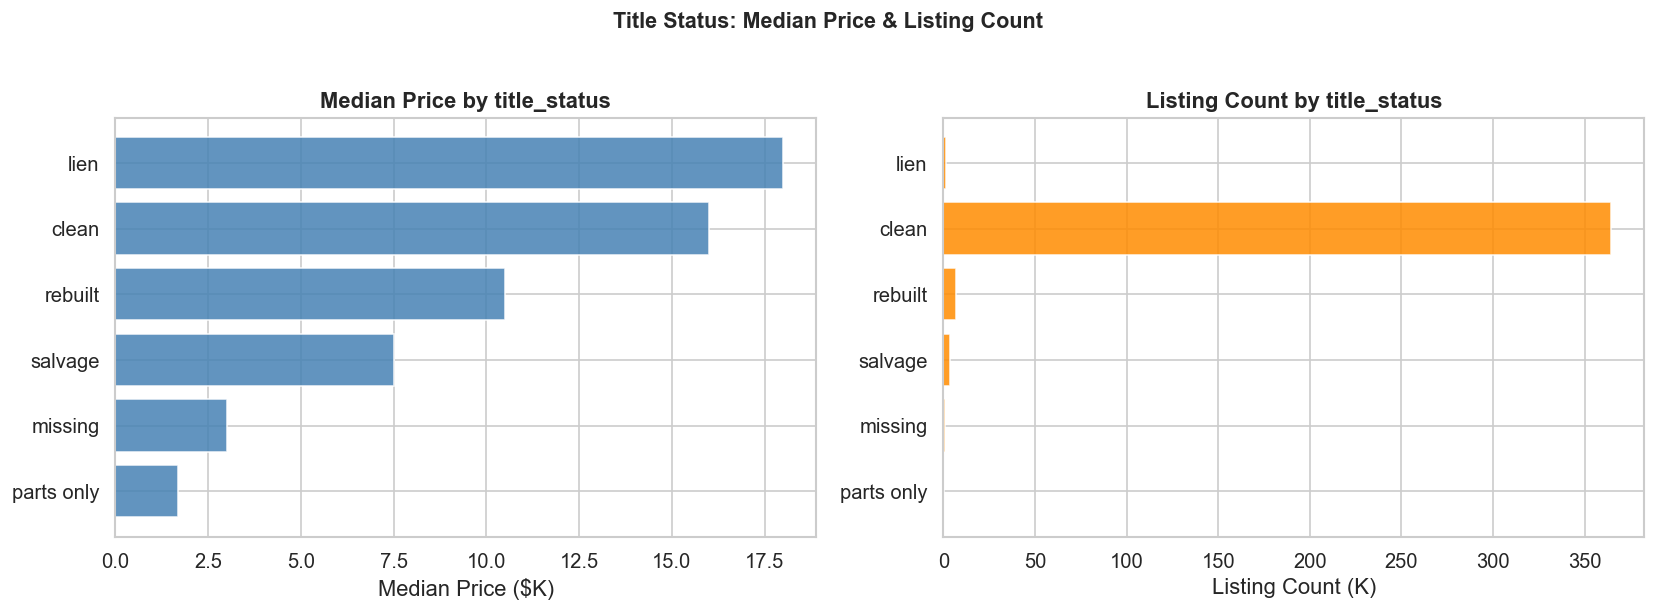

In [25]:
# ── Title Status ─────────────────────────────────────────────────────────────
plot_cat_price('title_status', top_n=8, title='Title Status: Median Price & Listing Count')

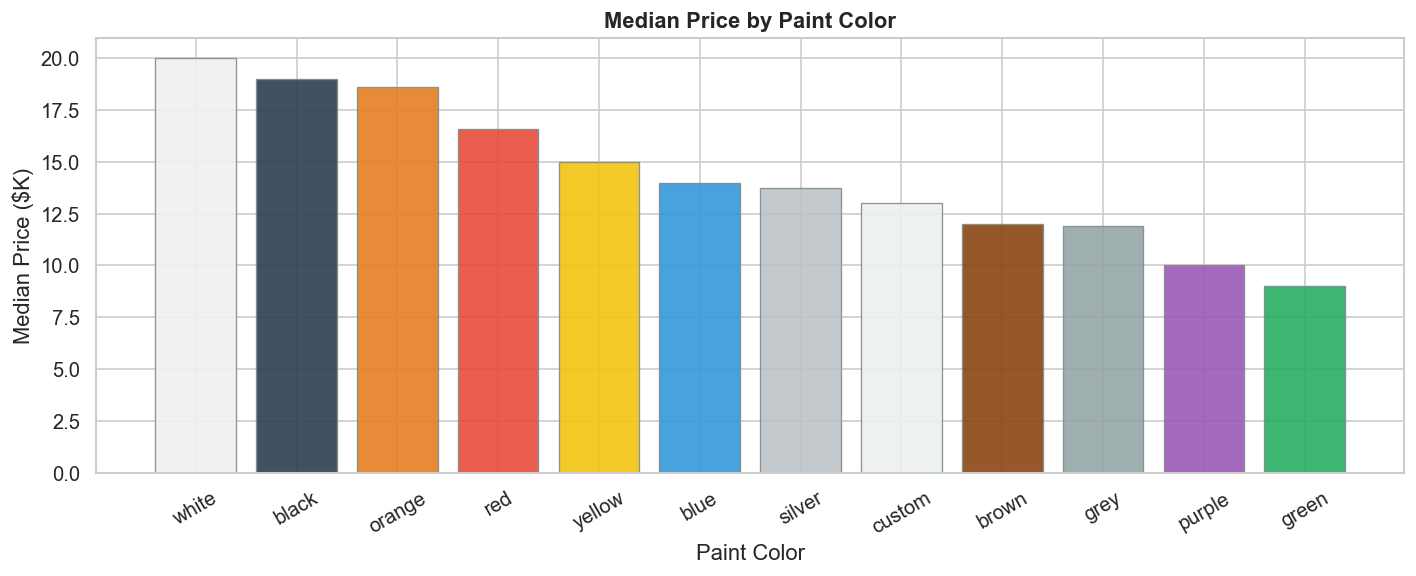

In [26]:
# ── Paint Color ──────────────────────────────────────────────────────────────
color_palette = {
    'white': '#f0f0f0', 'black': '#2c3e50', 'silver': '#bdc3c7',
    'red': '#e74c3c', 'blue': '#3498db', 'grey': '#95a5a6',
    'green': '#27ae60', 'brown': '#8B4513', 'orange': '#e67e22',
    'yellow': '#f1c40f', 'purple': '#9b59b6', 'custom': '#ecf0f1'
}

paint_data = (
    df.dropna(subset=['paint_color', 'price'])
    .groupby('paint_color')['price']
    .agg(median='median', count='count')
    .sort_values('median', ascending=False)
)

fig, ax = plt.subplots(figsize=(12, 5))
colors = [color_palette.get(c, '#7f8c8d') for c in paint_data.index]
bars = ax.bar(paint_data.index, paint_data['median'] / 1000,
              color=colors, edgecolor='#7f8c8d', linewidth=0.8, alpha=0.9)
ax.set_title('Median Price by Paint Color', fontweight='bold')
ax.set_xlabel('Paint Color')
ax.set_ylabel('Median Price ($K)')
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.savefig('../reports/figures/cat_paint_color.png', bbox_inches='tight')
plt.show()

---
## 7. Geographic Analysis <a id='7-geo'></a>

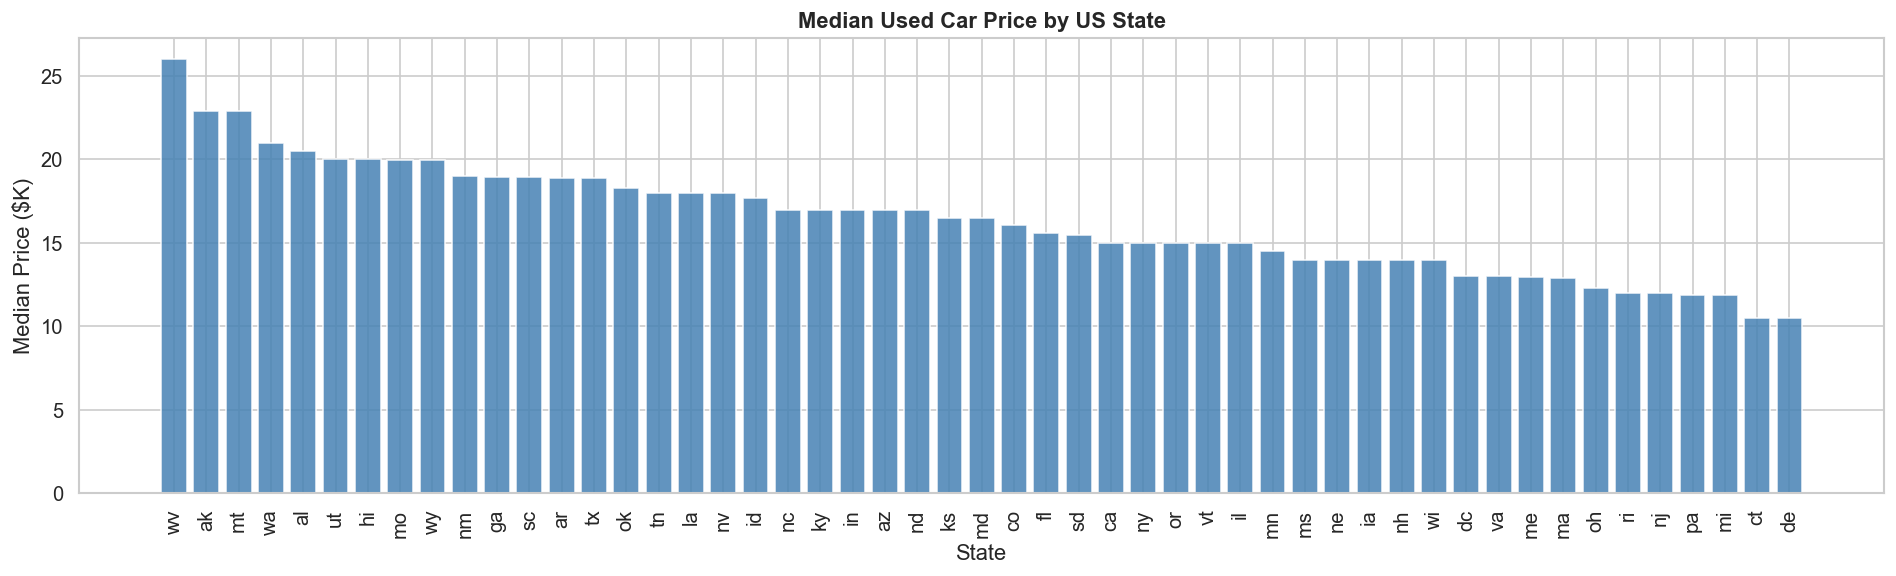

In [27]:
# Median price by US state
state_data = (
    df.dropna(subset=['state', 'price'])
    .groupby('state')
    .agg(median_price=('price', 'median'), count=('price', 'count'))
    .reset_index()
    .sort_values('median_price', ascending=False)
)

fig, ax = plt.subplots(figsize=(16, 5))
bars = ax.bar(state_data['state'], state_data['median_price'] / 1000,
              color='steelblue', alpha=0.85)
ax.set_title('Median Used Car Price by US State', fontweight='bold')
ax.set_xlabel('State')
ax.set_ylabel('Median Price ($K)')
ax.tick_params(axis='x', rotation=90)
plt.tight_layout()
plt.savefig('../reports/figures/06_price_by_state.png', bbox_inches='tight')
plt.show()

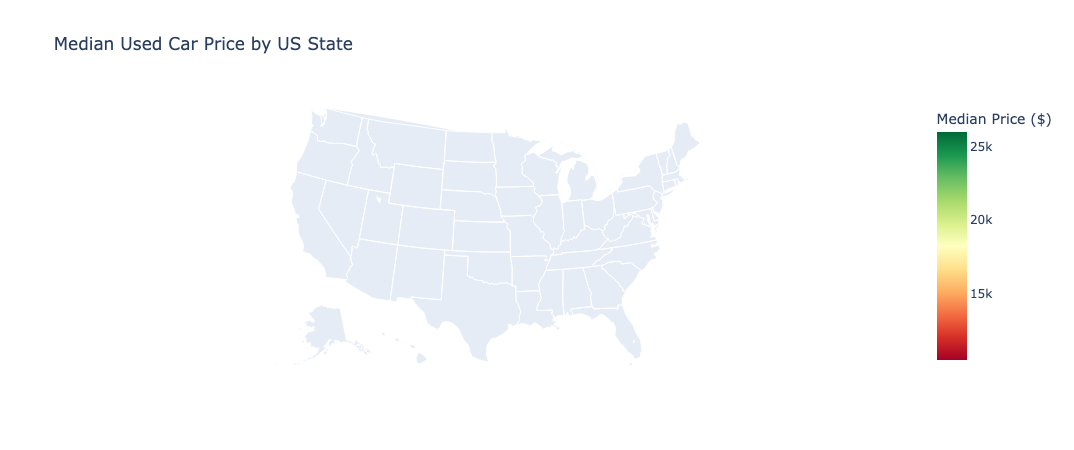

In [28]:
# Choropleth map using Plotly
fig_map = px.choropleth(
    state_data,
    locations='state',
    locationmode='USA-states',
    color='median_price',
    scope='usa',
    color_continuous_scale='RdYlGn',
    labels={'median_price': 'Median Price ($)'},
    title='Median Used Car Price by US State',
    hover_data=['count']
)
fig_map.update_layout(geo=dict(bgcolor='rgba(0,0,0,0)'), height=450)
fig_map.show()
fig_map.write_html('../reports/figures/map_price_by_state.html')

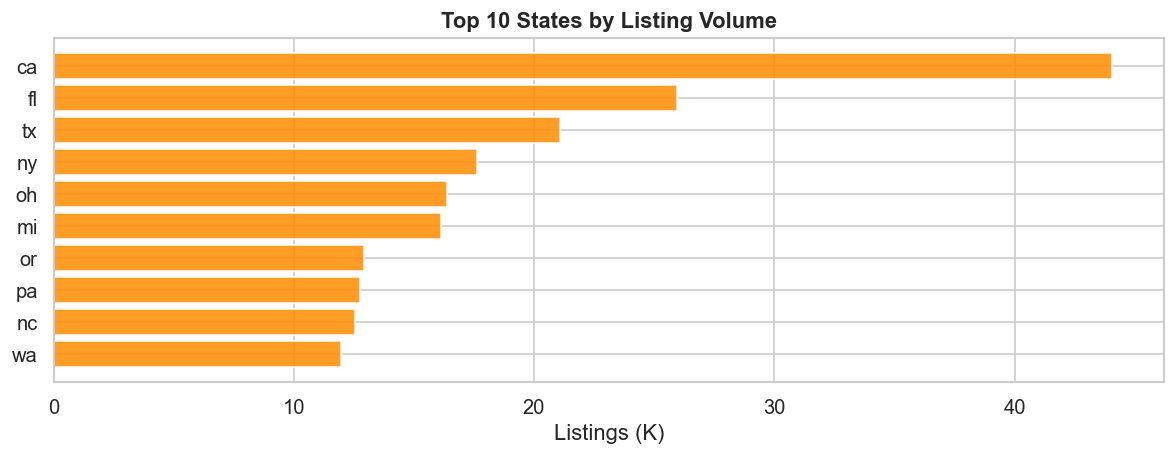

In [29]:
# Top 10 states by listing volume
top_states = state_data.sort_values('count', ascending=False).head(10)

fig, ax = plt.subplots(figsize=(10, 4))
ax.barh(top_states['state'], top_states['count'] / 1000, color='darkorange', alpha=0.85)
ax.set_xlabel('Listings (K)')
ax.set_title('Top 10 States by Listing Volume', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## 8. Feature Correlations <a id='8-correlations'></a>

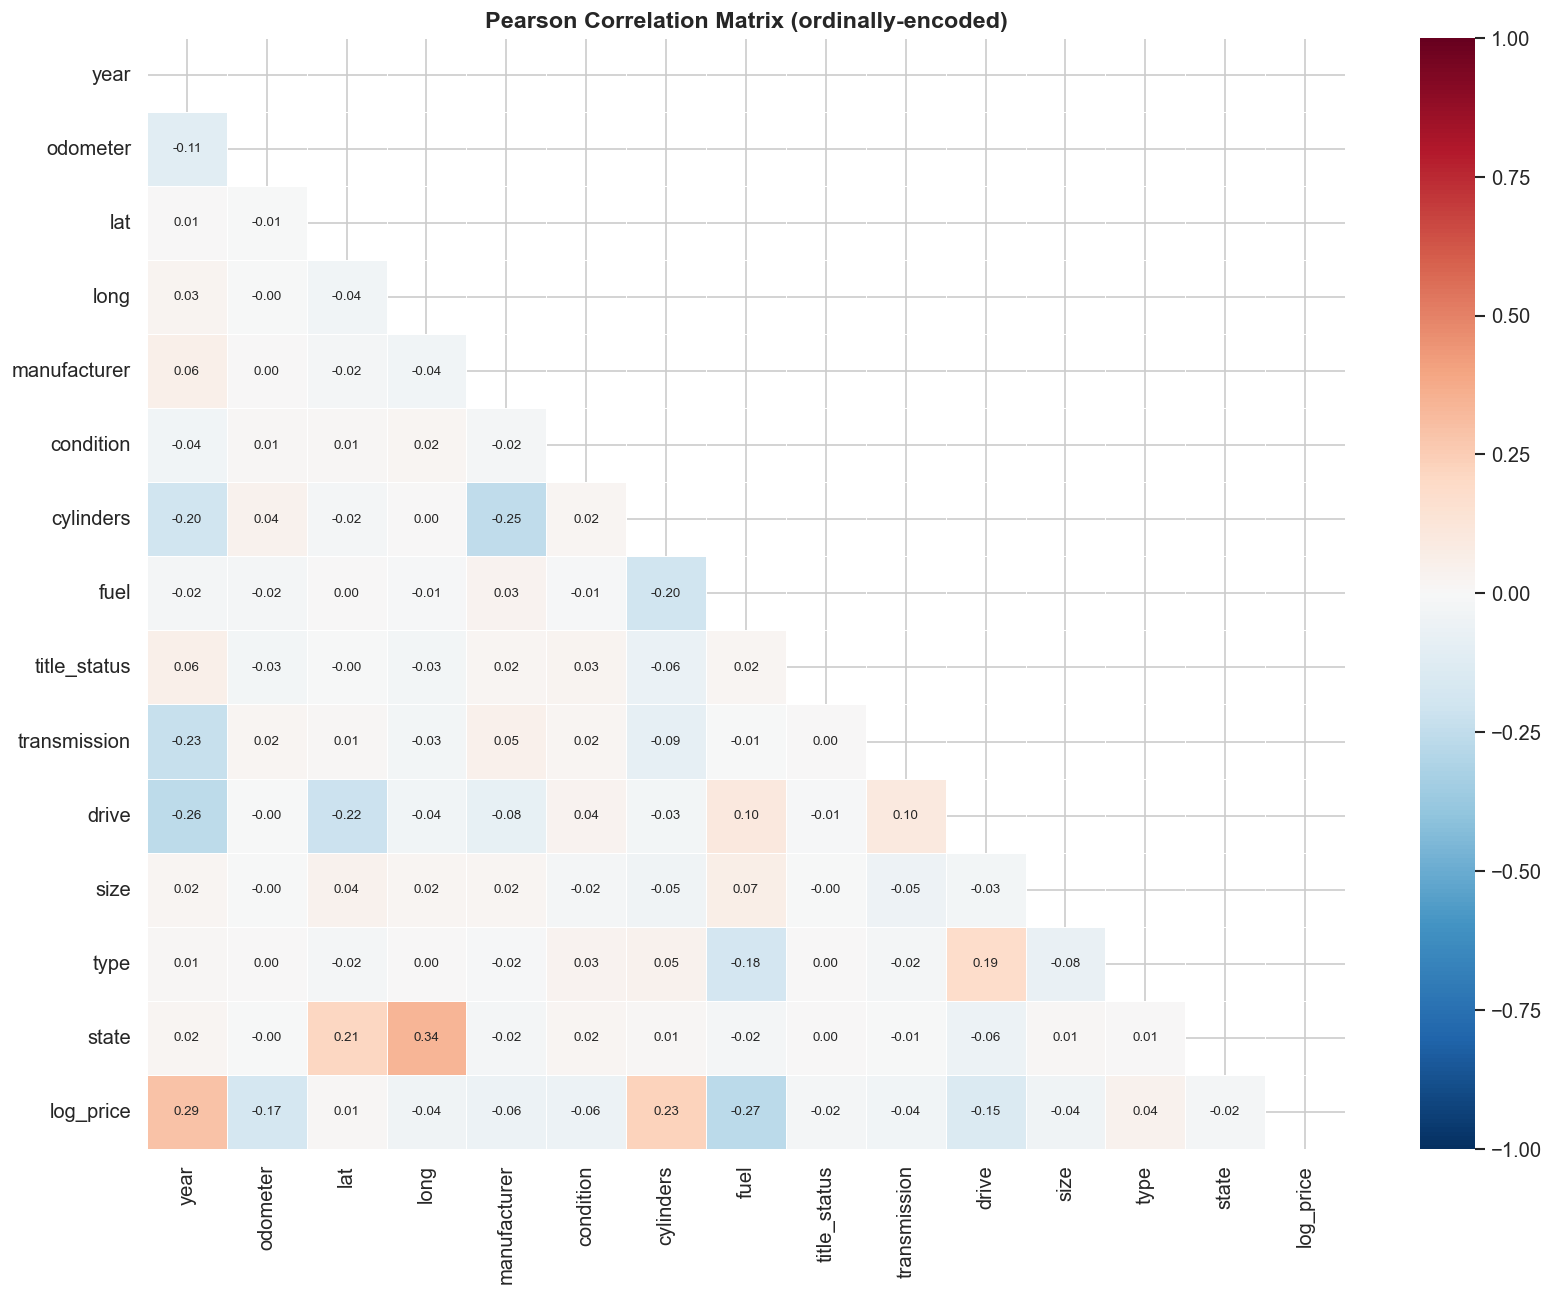

In [30]:
# Encode categorical features ordinally for correlation analysis
from sklearn.preprocessing import OrdinalEncoder

CAT_COLS = ['manufacturer', 'condition', 'cylinders', 'fuel',
            'title_status', 'transmission', 'drive', 'size', 'type', 'state']
NUM_COLS = ['year', 'odometer', 'lat', 'long']

df_corr = df[NUM_COLS + CAT_COLS + ['log_price']].copy()

enc = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)
df_corr[CAT_COLS] = enc.fit_transform(df_corr[CAT_COLS])
df_corr = df_corr.dropna()

corr_matrix = df_corr.corr()

fig, ax = plt.subplots(figsize=(14, 11))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
    center=0, vmin=-1, vmax=1, linewidths=0.5,
    annot_kws={'size': 8}, ax=ax
)
ax.set_title('Pearson Correlation Matrix (ordinally-encoded)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../reports/figures/07_correlation_matrix.png', bbox_inches='tight')
plt.show()

In [31]:
# Sorted correlation with target
target_corr = corr_matrix['log_price'].drop('log_price').sort_values(key=abs, ascending=False)
print('Correlation with log(price):')
print(target_corr.to_string())

Correlation with log(price):
year            0.289730
fuel           -0.269915
cylinders       0.227222
odometer       -0.174536
drive          -0.145715
condition      -0.061885
manufacturer   -0.058913
size           -0.044701
long           -0.042994
type            0.040836
transmission   -0.038234
state          -0.019694
title_status   -0.018011
lat             0.010957


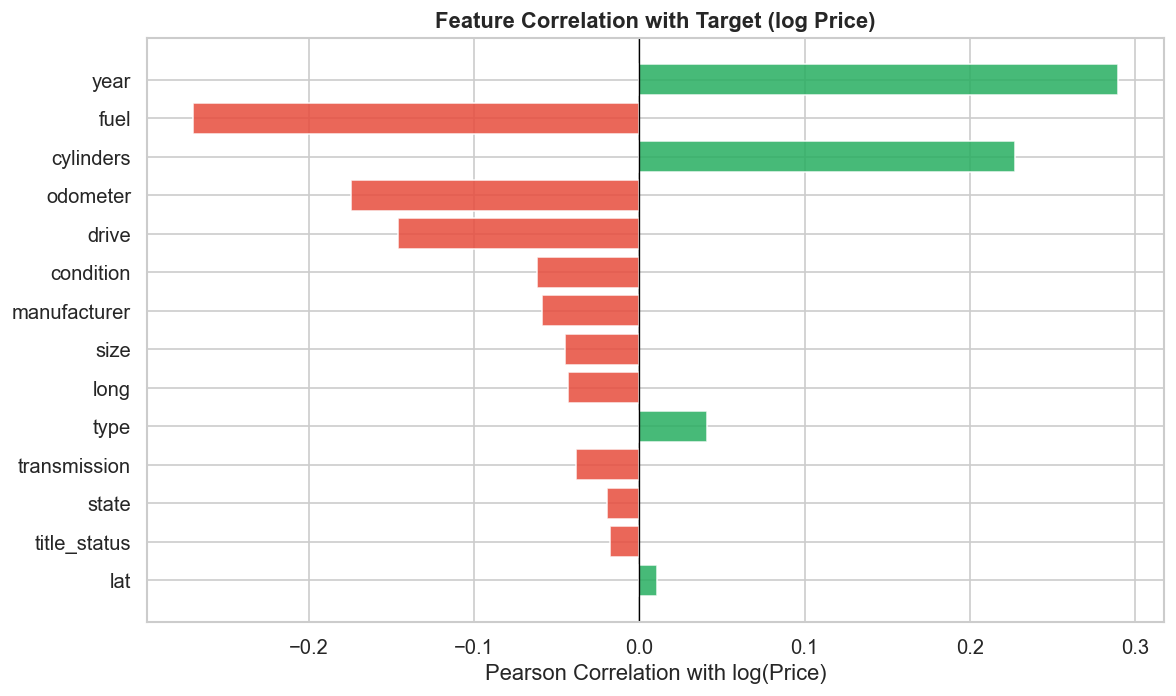

In [32]:
# Feature correlation with target — horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#27ae60' if v > 0 else '#e74c3c' for v in target_corr.values]
ax.barh(target_corr.index, target_corr.values, color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson Correlation with log(Price)')
ax.set_title('Feature Correlation with Target (log Price)', fontweight='bold')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('../reports/figures/08_target_correlations.png', bbox_inches='tight')
plt.show()

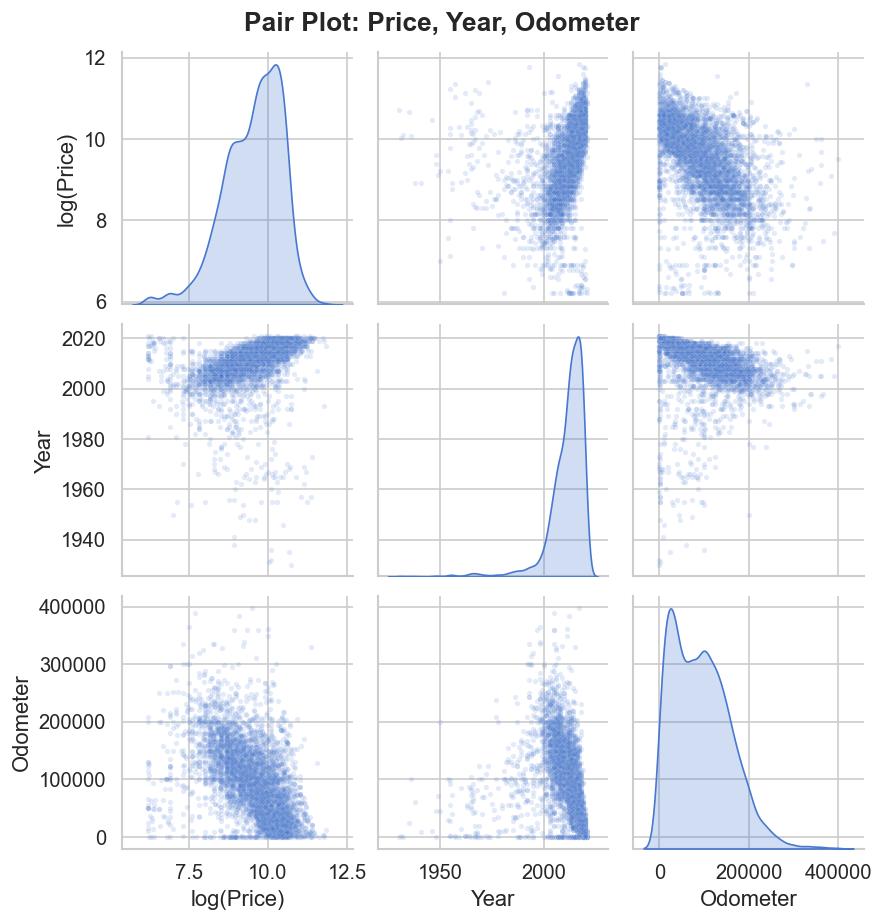

In [33]:
# Pair plot for core numerical features
pair_df = df[['log_price', 'year', 'odometer']].dropna().sample(5_000, random_state=SEED)
pair_df.columns = ['log(Price)', 'Year', 'Odometer']
pair_df = pair_df[pair_df['Odometer'] < 400_000]

g = sns.pairplot(pair_df, diag_kind='kde', plot_kws=dict(alpha=0.15, s=10))
g.fig.suptitle('Pair Plot: Price, Year, Odometer', y=1.02, fontweight='bold')
plt.savefig('../reports/figures/09_pairplot.png', bbox_inches='tight')
plt.show()

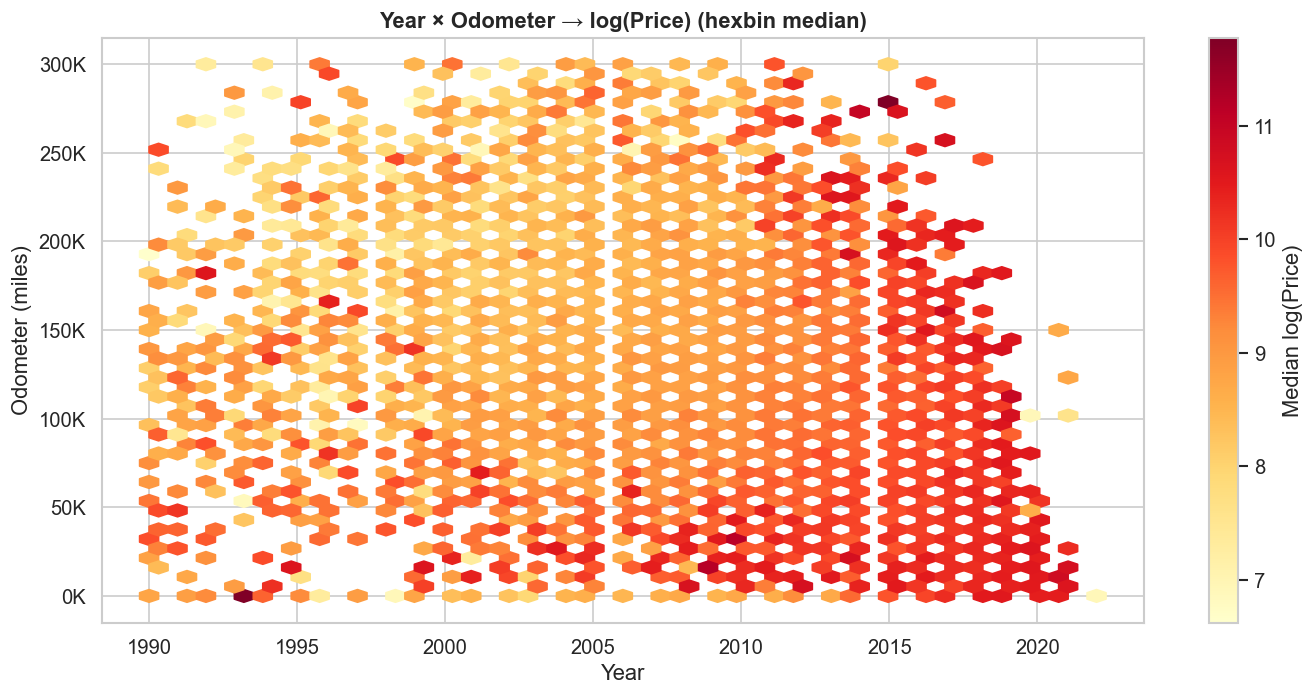

In [34]:
# Joint effect: year × odometer on price (hex-bin)
sample_joint = df[
    df['year'].between(1990, CURRENT_YEAR) &
    df['odometer'].between(0, 300_000)
].sample(30_000, random_state=SEED)

fig, ax = plt.subplots(figsize=(12, 6))
hb = ax.hexbin(
    sample_joint['year'], sample_joint['odometer'],
    C=sample_joint['log_price'],
    gridsize=50, reduce_C_function=np.median, cmap='YlOrRd'
)
cb = plt.colorbar(hb, ax=ax)
cb.set_label('Median log(Price)')
ax.set_title('Year × Odometer → log(Price) (hexbin median)', fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Odometer (miles)')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x/1000:.0f}K'))
plt.tight_layout()
plt.savefig('../reports/figures/10_year_odo_hexbin.png', bbox_inches='tight')
plt.show()

---
## 9. Key Insights & Preprocessing Implications <a id='9-insights'></a>

### Summary of EDA Findings

| # | Finding | Implication for Preprocessing / Modeling |
|---|---|---|
| 1 | **Price** is extremely right-skewed with many bogus values (0, 1, 999999) | Filter to `[$500, $150K]`; model on `log1p(price)` |
| 2 | **Year** has strong positive correlation with price; some listings show year=0 or >2025 | Filter `[1980, 2025]`; derive `vehicle_age = 2025 − year` |
| 3 | **Odometer** has strong negative correlation; values >400K are likely errors | Cap at 400K or remove; consider `log1p(odometer)` |
| 4 | **Manufacturer** has 40+ unique values with very unequal representation | Target-encode or use frequency encoding; lump rare (<0.5%) into `other` |
| 5 | **Condition** has a clear ordinal relationship with price (new > like new > ...) | Ordinal encode with semantic order |
| 6 | **Cylinders** is stored as string (`"4 cylinders"`) | Parse to integer; treat `"other"` separately |
| 7 | `size` has ~72% missing; `county` has ~100% missing | Drop `size` and `county`; impute others with mode or `'unknown'` |
| 8 | **Title status** dramatically affects price (salvage = ~50% of clean title) | Keep as categorical; high signal |
| 9 | **State** shows geographic price variation | Include as categorical; consider regional median as a numeric feature |
| 10 | **Paint color** has only minor effect on price | Include but low-priority feature |

### Next Steps

➜ **Notebook 02 — Preprocessing:**  
- Apply all filters above  
- Engineer features: `vehicle_age`, `log_odometer`, `cylinders_int`, region median price  
- Encode categoricals  
- Train / validation / test split (60 / 20 / 20)  

➜ **Notebook 03 — Modeling:**  
- Baseline: Ridge Regression  
- Random Forest, XGBoost, LightGBM  
- Hyperparameter tuning via cross-validation  

➜ **Notebook 04 — XAI:**  
- Global: SHAP summary plots, permutation importance  
- Local: SHAP waterfall / force plots, LIME explanations  
- Feature effects: PDP, ICE plots for top features  

In [35]:
# Save a clean analysis copy for next notebook
df_clean_preview = df[
    df['year'].between(1980, CURRENT_YEAR) &
    df['odometer'].between(0, 400_000)
].copy()

df_clean_preview['vehicle_age'] = CURRENT_YEAR - df_clean_preview['year']
df_clean_preview['log_odometer'] = np.log1p(df_clean_preview['odometer'])

print(f'Preview clean frame: {df_clean_preview.shape[0]:,} rows')
print(f'Remaining missing values:')
print(
    df_clean_preview.isnull().sum()[df_clean_preview.isnull().sum() > 0]
    .sort_values(ascending=False)
    .to_string()
)

Preview clean frame: 372,234 rows
Remaining missing values:
size            268211
cylinders       152693
condition       140951
drive           112709
paint_color     107083
type             78546
manufacturer     12234
title_status      6488
model             3660
lat               3371
long              3371
fuel              2109
transmission      1506


---
*EDA complete. Proceed to `02_Preprocessing.ipynb`.*